# ECG Heartbeat Classification

# Theme : Healthcare

**Team Members:**  Yassine El Gares, Mohamed Aziz Missaoui, Rayen Chaibi, Yassine Maazouz


**Notebook Goal:**  Compare four distinct machine learning models for 5-class ECG heartbeat classification, then interpret predictions in both fine-grained and normal-vs-abnormal form.

<div style="border-left:6px solid #1D9E75;background:linear-gradient(90deg,#E1F5EE 0%,#F7FCFA 100%);border-radius:0 12px 12px 0;padding:14px 18px;margin:8px 0 14px 0;">
  <div style="font-size:12px;letter-spacing:0.08em;text-transform:uppercase;color:#0F6E56;font-weight:800;">Section 1</div>
  <div style="font-size:24px;color:#085041;font-weight:800;margin-top:2px;">Problem Definition</div>
</div>

We solve a **supervised multiclass classification** problem.

- **Input:** one ECG heartbeat vector with 187 signal values
- **Output:** one of five heartbeat classes
- **Classes:**
  - `N` = Normal beat
  - `S` = Supraventricular ectopic beat
  - `V` = Ventricular ectopic beat
  - `F` = Fusion beat
  - `Q` = Unclassifiable beat




<div style="border-left:3px solid #D98E04;background:#FFF4D9;border-radius:0 8px 8px 0;padding:10px 14px;margin:12px 0 4px 0;">
  <strong style="color:#7C5200">Evaluation note</strong><br>
  <span style="color:#8A6400;font-size:13px">Because the heartbeat classes are imbalanced, the notebook emphasizes macro F1-score and macro recall instead of relying on accuracy alone.</span>
</div>


### Library imports

These libraries are used for data handling, visualization, model training, hyperparameter tuning, and evaluation.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

### Project constants and paths

This cell defines reproducibility settings, dataset paths, feature names, and the label meanings used throughout the notebook.

In [2]:
RANDOM_STATE = 42
COMPARISON_SUBSET_SIZE = 12_000

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
TRAIN_PATH = DATA_DIR / 'mitbih_train.csv'
TEST_PATH = DATA_DIR / 'mitbih_test.csv'

LABEL_MAP = {
    0: 'N',
    1: 'S',
    2: 'V',
    3: 'F',
    4: 'Q',
}

LABEL_DESCRIPTION = {
    0: 'Normal beat',
    1: 'Supraventricular ectopic beat',
    2: 'Ventricular ectopic beat',
    3: 'Fusion beat',
    4: 'Unclassifiable beat',
}

BINARY_MAP = {
    0: 'Normal',
    1: 'Abnormal',
    2: 'Abnormal',
    3: 'Abnormal',
    4: 'Abnormal',
}

FEATURE_COLUMNS = [f'signal_{i:03d}' for i in range(187)]
CSV_DTYPES = {**{idx: 'float32' for idx in range(187)}, 187: 'int8'}

<div style="border-left:6px solid #1D9E75;background:linear-gradient(90deg,#E1F5EE 0%,#F7FCFA 100%);border-radius:0 12px 12px 0;padding:14px 18px;margin:8px 0 14px 0;">
  <div style="font-size:12px;letter-spacing:0.08em;text-transform:uppercase;color:#0F6E56;font-weight:800;">Section 2</div>
  <div style="font-size:24px;color:#085041;font-weight:800;margin-top:2px;">Dataset Loading</div>
</div>

The official dataset files are loaded from the local `data/` directory. The notebook keeps the **official test set reserved for final evaluation** and does not use it for tuning or model selection.




In [3]:
#reading the 2 csv files 
train_df = pd.read_csv(TRAIN_PATH, header=None, dtype=CSV_DTYPES)
test_df = pd.read_csv(TEST_PATH, header=None, dtype=CSV_DTYPES)


#renaming the columns 
train_df.columns = FEATURE_COLUMNS + ['label']
test_df.columns = FEATURE_COLUMNS + ['label']

#Shows the dataset size and first few rows
print('Training shape:', train_df.shape)
print('Official test shape:', test_df.shape)


Training shape: (87554, 188)
Official test shape: (21892, 188)





Before training the model, we check the distribution of the target classes.

In [4]:
#count samples per class 
train_class_counts = train_df['label'].value_counts().sort_index()

#shows info about each class    
train_class_table = pd.DataFrame({
    'class_id': train_class_counts.index,
    'class_code': [LABEL_MAP[int(idx)] for idx in train_class_counts.index],
    'heartbeat_type': [LABEL_DESCRIPTION[int(idx)] for idx in train_class_counts.index],
    'count': train_class_counts.values,
    'share_%': (100 * train_class_counts.values / len(train_df)).round(2),
})

display(train_class_table)

,class_id,class_code,heartbeat_type,count,share_%
0,0,N,Normal beat,72471,82.77
1,1,S,Supraventricular ectopic beat,2223,2.54
2,2,V,Ventricular ectopic beat,5788,6.61
3,3,F,Fusion beat,641,0.73
4,4,Q,Unclassifiable beat,6431,7.35


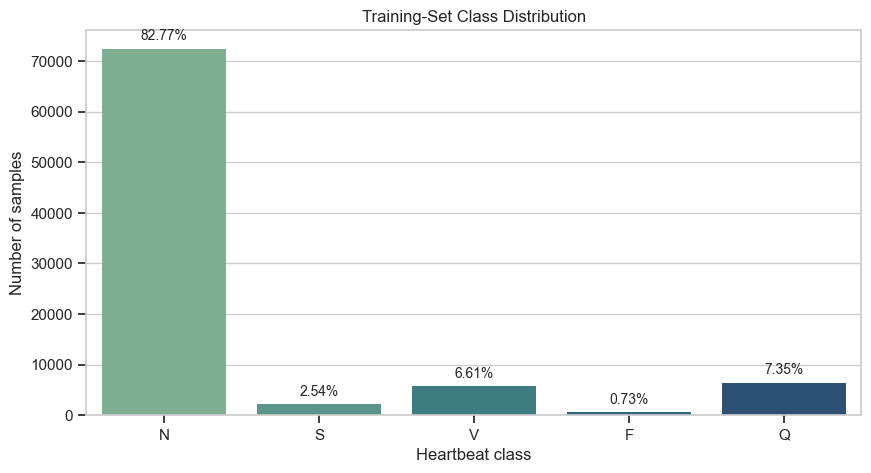

In [5]:
#This code creates a bar chart showing the number of ECG samples in each heartbeat class, then writes the percentage above each bar.

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=train_class_table, x='class_code', y='count', palette='crest')
ax.set_title('Training-Set Class Distribution')
ax.set_xlabel('Heartbeat class')
ax.set_ylabel('Number of samples')
for patch, pct in zip(ax.patches, train_class_table['share_%']):
    ax.annotate(f'{pct:.2f}%', (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 4), textcoords='offset points')
plt.show()

### Example ECG Waveforms by Class

The dataset is not just rows of numbers: each row is a short ECG heartbeat signal. Plotting one example from each class makes the classification task easier to understand before comparing models.

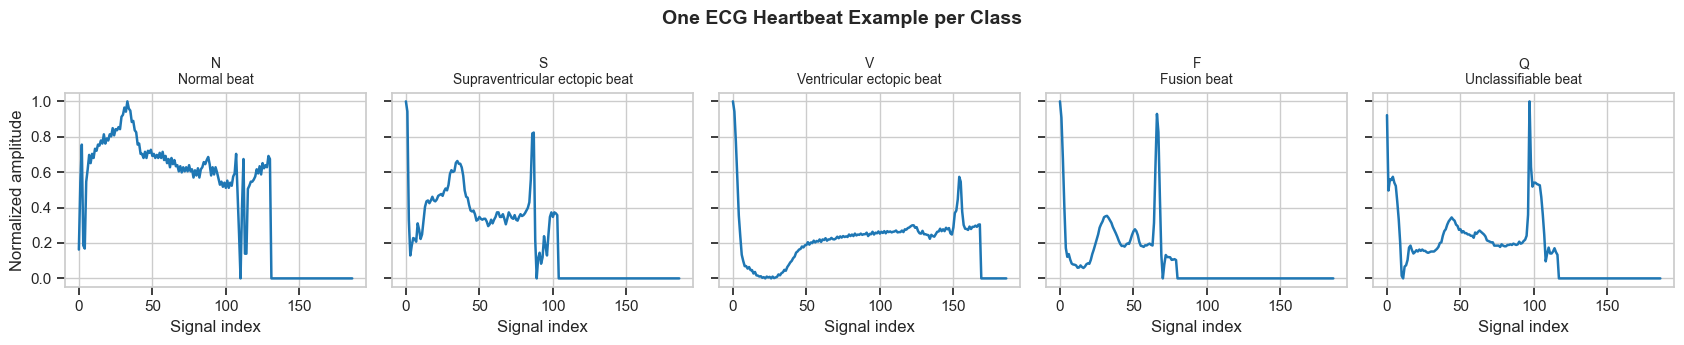

In [6]:
example_waveforms = (
    train_df.groupby('label', group_keys=False)
    .sample(n=1, random_state=RANDOM_STATE)
    .sort_values('label')
)

fig, axes = plt.subplots(1, len(LABEL_MAP), figsize=(17, 3.5), sharey=True)

for ax, (_, row) in zip(axes, example_waveforms.iterrows()):
    class_id = int(row['label'])
    signal = row[FEATURE_COLUMNS].to_numpy(dtype=float)

    ax.plot(signal, linewidth=1.8)
    ax.set_title(f"{LABEL_MAP[class_id]}\n{LABEL_DESCRIPTION[class_id]}", fontsize=10)
    ax.set_xlabel('Signal index')
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel('Normalized amplitude')
fig.suptitle('One ECG Heartbeat Example per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="border-left:6px solid #1D9E75;background:linear-gradient(90deg,#E1F5EE 0%,#F7FCFA 100%);border-radius:0 12px 12px 0;padding:14px 18px;margin:8px 0 14px 0;">
  <div style="font-size:12px;letter-spacing:0.08em;text-transform:uppercase;color:#0F6E56;font-weight:800;">Section 3</div>
  <div style="font-size:24px;color:#085041;font-weight:800;margin-top:2px;"> Comparison </div>
</div>

To keep the comparison fair and computationally manageable, all candidate models use the **same stratified 12,000-row subset** sampled from the training file. That subset is then split into a training partition and a validation partition.




In [7]:
#create a comparaison subset 
comparison_subset_df, _ = train_test_split(
    train_df,
    train_size=COMPARISON_SUBSET_SIZE,
    stratify=train_df['label'],
    random_state=RANDOM_STATE,
)

#Split the comparison subset into train and validation
compare_train_df, compare_val_df = train_test_split(
    comparison_subset_df,
    test_size=0.20,
    stratify=comparison_subset_df['label'],
    random_state=RANDOM_STATE,
)

#Separate features and labels for the full comparison subset
X_compare = comparison_subset_df[FEATURE_COLUMNS]
y_compare = comparison_subset_df['label']

X_train = compare_train_df[FEATURE_COLUMNS]
y_train = compare_train_df['label']

X_val = compare_val_df[FEATURE_COLUMNS]
y_val = compare_val_df['label']

X_test = test_df[FEATURE_COLUMNS]
y_test = test_df['label']

print('Comparison subset shape:', X_compare.shape)
print('Training partition shape:', X_train.shape)
print('Validation partition shape:', X_val.shape)
print('Official test shape:', X_test.shape)


Comparison subset shape: (12000, 187)
Training partition shape: (9600, 187)
Validation partition shape: (2400, 187)
Official test shape: (21892, 187)


<div style="border-left:6px solid #1D9E75;background:linear-gradient(90deg,#E1F5EE 0%,#F7FCFA 100%);border-radius:0 12px 12px 0;padding:14px 18px;margin:8px 0 14px 0;">
  <div style="font-size:12px;letter-spacing:0.08em;text-transform:uppercase;color:#0F6E56;font-weight:800;">Section 4</div>
  <div style="font-size:24px;color:#085041;font-weight:800;margin-top:2px;">Candidate Models</div>
</div>

We will compare four distinct models. This selection gives a stronger scientific comparison than using multiple models that are all minor variations of the same principle.

<div style="margin:14px 0 10px 0;">
  <span style="display:inline-block;background:#EEF5FF;color:#0B4DA2;border:1px solid #C9DDFF;border-radius:999px;padding:5px 11px;margin:4px 6px 0 0;font-size:12px;font-weight:700;">Logistic Regression -> linear probabilistic baseline</span>
  <span style="display:inline-block;background:#EAF8F2;color:#0F6E56;border:1px solid #B7E8D7;border-radius:999px;padding:5px 11px;margin:4px 6px 0 0;font-size:12px;font-weight:700;">KNN -> similarity-based classifier</span>
  <span style="display:inline-block;background:#FFF3E6;color:#9A4E00;border:1px solid #FFD6A3;border-radius:999px;padding:5px 11px;margin:4px 6px 0 0;font-size:12px;font-weight:700;">Random Forest -> nonlinear tree ensemble</span>
  <span style="display:inline-block;background:#F3EDFF;color:#5B2E91;border:1px solid #DCCBFF;border-radius:999px;padding:5px 11px;margin:4px 6px 0 0;font-size:12px;font-weight:700;">SVM -> margin-based nonlinear classifier</span>
</div>


### Metrics From Class

The notebook uses the same confusion-matrix metrics studied in class. For a binary classification case:

```text
Accuracy = (TP + TN) / (TP + TN + FP + FN)

Precision = TP / (TP + FP)

Recall = TP / (TP + FN)

F1 = 2 * Precision * Recall / (Precision + Recall)
```

For the 5-class ECG problem, these formulas are computed for each class using a one-vs-rest view. The notebook mainly reports **macro** averages, meaning each class receives equal importance:

```text
Macro metric = (metric_N + metric_S + metric_V + metric_F + metric_Q) / 5
```

This is why macro F1 and macro recall are more useful than accuracy alone for this imbalanced healthcare dataset.

### Evaluation helper

This helper applies the same metrics to every candidate model so the comparison remains fair.

In [8]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def evaluate_predictions(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'abnormal_macro_recall': recall_score(
            y_true,
            y_pred,
            average='macro',
            labels=[1, 2, 3, 4],
            zero_division=0,
        ),
    }

### Model definitions

Each model uses the same training and validation protocol, but represents a different modelling idea.

In [10]:
model_specs = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ]),
        'param_grid': {
            'model__C': [0.1, 1.0, 3.0],
            'model__class_weight': [None, 'balanced'],
        },
        'short_role': 'Linear probabilistic baseline',
    },
    'K-Nearest Neighbors': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('model', KNeighborsClassifier(n_jobs=-1)),
        ]),
        'param_grid': {
            'model__n_neighbors': [3, 5, 9],
            'model__weights': ['uniform', 'distance'],
            'model__metric': ['euclidean', 'manhattan'],
        },
        'short_role': 'Similarity-based classifier',
    },
    'Random Forest': {
        'pipeline': Pipeline([
            ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
        'param_grid': {
            'model__n_estimators': [200],
            'model__max_depth': [None, 20],
            'model__min_samples_leaf': [1, 3],
            'model__class_weight': [None, 'balanced_subsample'],
        },
        'short_role': 'Nonlinear tree ensemble',
    },
    'Support Vector Machine': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('model', SVC(kernel='rbf')),
        ]),
        'param_grid': {
            'model__C': [1.0, 3.0],
            'model__gamma': ['scale', 0.01],
        },
        'short_role': 'Margin-based nonlinear classifier',
    },
}

### Model overview table

This table summarizes why each model is included in the benchmark.

In [11]:
model_overview = pd.DataFrame({
    'Model': list(model_specs.keys()),
    'Role in comparison': [spec['short_role'] for spec in model_specs.values()],
    'Primary tuning focus': [
        'C, class_weight',
        'n_neighbors, weights, metric',
        'n_estimators, max_depth, min_samples_leaf, class_weight',
        'C, gamma',
    ],
})

display(model_overview)

,Model,Role in comparison,Primary tuning focus
0,Logistic Regression,Linear probabilistic baseline,"C, class_weight"
1,K-Nearest Neighbors,Similarity-based classifier,"n_neighbors, weights, metric"
2,Random Forest,Nonlinear tree ensemble,"n_estimators, max_depth, min_samples_leaf, cla..."
3,Support Vector Machine,Margin-based nonlinear classifier,"C, gamma"


<div style="border-left:6px solid #1D9E75;background:linear-gradient(90deg,#E1F5EE 0%,#F7FCFA 100%);border-radius:0 12px 12px 0;padding:14px 18px;margin:8px 0 14px 0;">
  <div style="font-size:12px;letter-spacing:0.08em;text-transform:uppercase;color:#0F6E56;font-weight:800;">Section 5</div>
  <div style="font-size:24px;color:#085041;font-weight:800;margin-top:2px;">Hyperparameter Tuning</div>
</div>

Each model is tuned under the same protocol:

- input data: training partition only
- cross-validation: `StratifiedKFold(n_splits=3)`
- scoring metric: `f1_macro`

<div style="border-left:3px solid #1D9E75;background:#E1F5EE;border-radius:0 8px 8px 0;padding:10px 14px;margin:12px 0 4px 0;">
  <strong style="color:#085041">Protocol note</strong><br>
  <span style="color:#0F6E56;font-size:13px">The validation partition is intentionally kept outside the cross-validation loop so it can support an honest model-selection step afterward.</span>
</div>


In [12]:
search_results = {}
validation_predictions = {}
cv_best_rows = []

for model_name, spec in model_specs.items():
    print(f'Running grid search for {model_name}...')
    search = GridSearchCV(
        estimator=spec['pipeline'],
        param_grid=spec['param_grid'],
        scoring='f1_macro',
        cv=cv,
        n_jobs=1,
        refit=True,
        verbose=0,
    )
    search.fit(X_train, y_train)

    y_val_pred = search.best_estimator_.predict(X_val)
    validation_predictions[model_name] = y_val_pred

    metrics = evaluate_predictions(y_val, y_val_pred)
    search_results[model_name] = {
        'search': search,
        'best_estimator': search.best_estimator_,
        'best_params': search.best_params_,
        'validation_metrics': metrics,
    }

    cv_results = pd.DataFrame(search.cv_results_)[['params', 'mean_test_score', 'rank_test_score']]
    best_row = cv_results.sort_values(['rank_test_score', 'mean_test_score'], ascending=[True, False]).head(1).copy()
    best_row.insert(0, 'model', model_name)
    cv_best_rows.append(best_row)

    print(f"  best CV macro F1: {search.best_score_:.4f}")
    print(f"  validation macro F1: {metrics['macro_f1']:.4f}")
    print(f"  best params: {search.best_params_}\n")

cv_summary = pd.concat(cv_best_rows, ignore_index=True)
display(cv_summary)

Running grid search for Logistic Regression...
  best CV macro F1: 0.6207
  validation macro F1: 0.6282
  best params: {'model__C': 3.0, 'model__class_weight': None}

Running grid search for K-Nearest Neighbors...
  best CV macro F1: 0.8071
  validation macro F1: 0.8367
  best params: {'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'distance'}

Running grid search for Random Forest...
  best CV macro F1: 0.8143
  validation macro F1: 0.8532
  best params: {'model__class_weight': 'balanced_subsample', 'model__max_depth': None, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}

Running grid search for Support Vector Machine...
  best CV macro F1: 0.7954
  validation macro F1: 0.8496
  best params: {'model__C': 3.0, 'model__gamma': 0.01}



,model,params,mean_test_score,rank_test_score
0,Logistic Regression,"{'model__C': 3.0, 'model__class_weight': None}",0.620726,1
1,K-Nearest Neighbors,"{'model__metric': 'euclidean', 'model__n_neigh...",0.807066,1
2,Random Forest,"{'model__class_weight': 'balanced_subsample', ...",0.814315,1
3,Support Vector Machine,"{'model__C': 3.0, 'model__gamma': 0.01}",0.795374,1


<div style="border-left:6px solid #1D9E75;background:linear-gradient(90deg,#E1F5EE 0%,#F7FCFA 100%);border-radius:0 12px 12px 0;padding:14px 18px;margin:8px 0 14px 0;">
  <div style="font-size:12px;letter-spacing:0.08em;text-transform:uppercase;color:#0F6E56;font-weight:800;">Section 6</div>
  <div style="font-size:24px;color:#085041;font-weight:800;margin-top:2px;">Validation Performance and Model Benchmark</div>
</div>

The validation partition is used to compare the tuned models under identical conditions. This section provides the evidence used for model selection.


In [13]:
comparison_rows = []
for model_name, result in search_results.items():
    metrics = result['validation_metrics']
    comparison_rows.append({
        'Model': model_name,
        'Accuracy': metrics['accuracy'],
        'Macro Precision': metrics['macro_precision'],
        'Macro Recall': metrics['macro_recall'],
        'Macro F1': metrics['macro_f1'],
        'Abnormal Macro Recall': metrics['abnormal_macro_recall'],
        'Best Params': str(result['best_params']),
    })

model_comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=['Macro F1', 'Macro Recall', 'Abnormal Macro Recall', 'Accuracy'],
    ascending=False,
).reset_index(drop=True)

display(model_comparison_df.round(4))

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Abnormal Macro Recall,Best Params
0,Random Forest,0.9654,0.9517,0.7869,0.8532,0.7348,"{'model__class_weight': 'balanced_subsample', ..."
1,Support Vector Machine,0.9629,0.9338,0.7913,0.8496,0.7398,"{'model__C': 3.0, 'model__gamma': 0.01}"
2,K-Nearest Neighbors,0.9596,0.8942,0.7915,0.8367,0.7416,"{'model__metric': 'euclidean', 'model__n_neigh..."
3,Logistic Regression,0.9062,0.6959,0.5882,0.6282,0.4915,"{'model__C': 3.0, 'model__class_weight': None}"


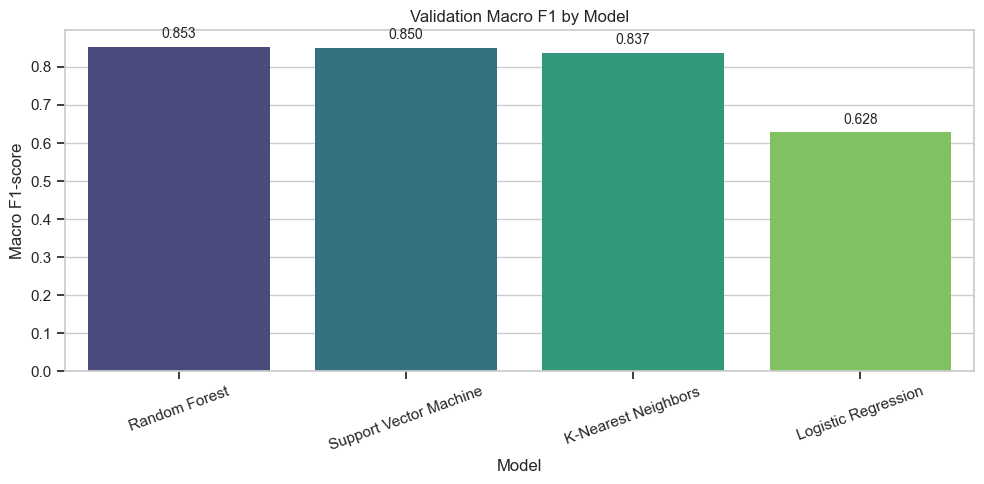

In [14]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=model_comparison_df, x='Model', y='Macro F1', palette='viridis')
ax.set_title('Validation Macro F1 by Model')
ax.set_ylabel('Macro F1-score')
ax.set_xlabel('Model')
ax.tick_params(axis='x', rotation=20)
for patch in ax.patches:
    ax.annotate(f'{patch.get_height():.3f}',
                (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 4), textcoords='offset points')
plt.tight_layout()
plt.show()

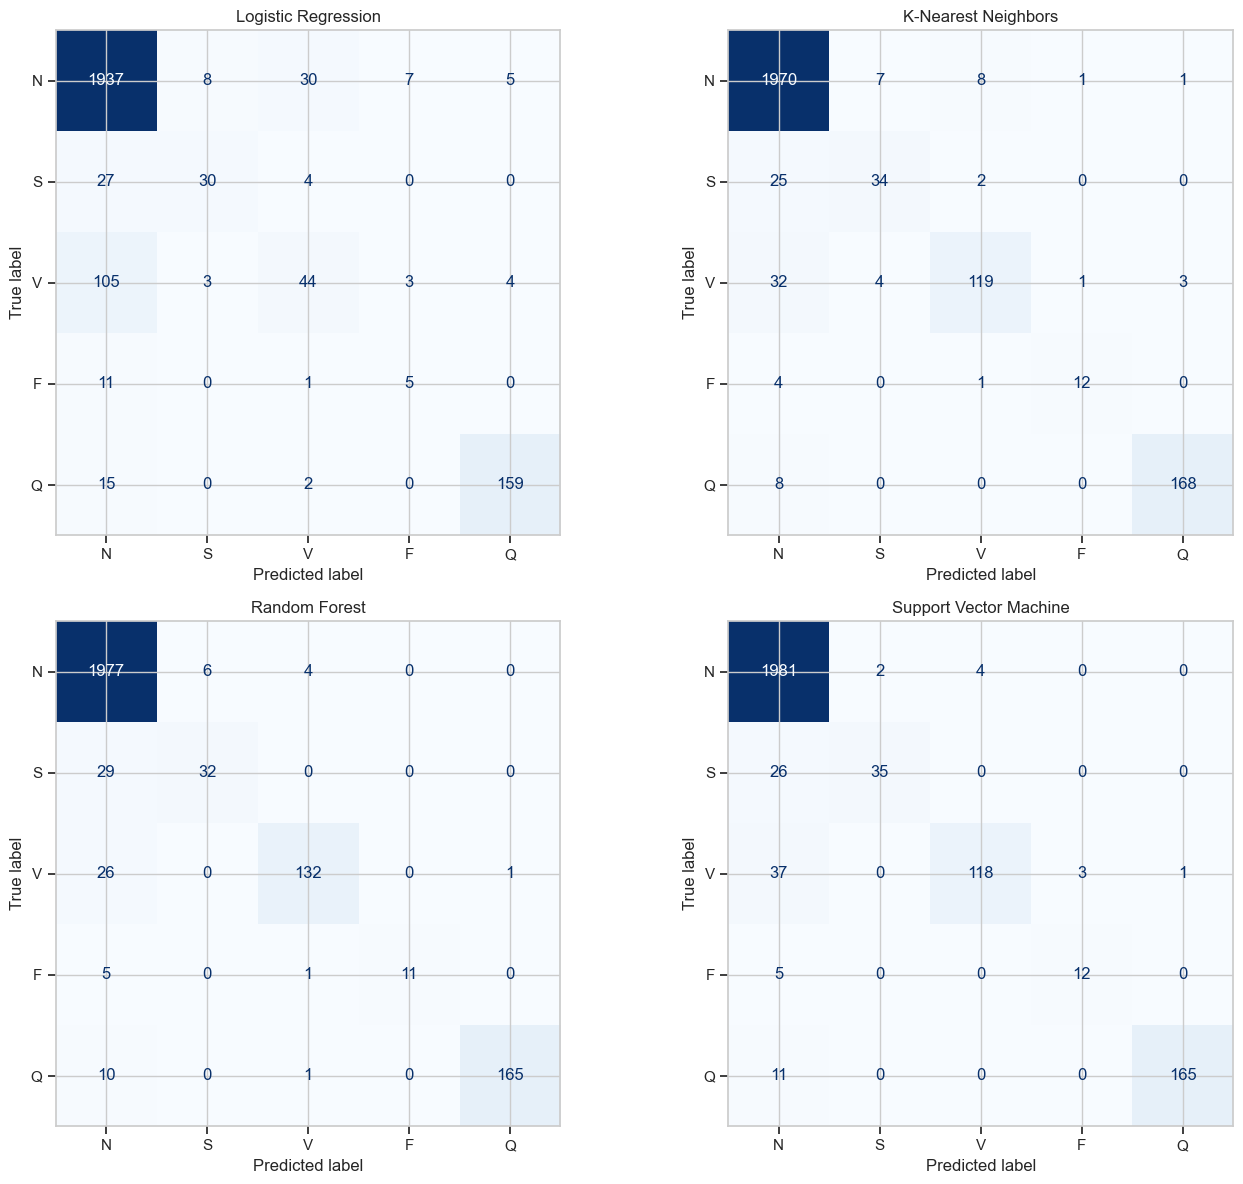

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
labels = sorted(LABEL_MAP)
display_labels = [LABEL_MAP[idx] for idx in labels]

for ax, (model_name, y_val_pred) in zip(axes, validation_predictions.items()):
    cm = confusion_matrix(y_val, y_val_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

<div style="border-left:6px solid #1D9E75;background:linear-gradient(90deg,#E1F5EE 0%,#F7FCFA 100%);border-radius:0 12px 12px 0;padding:14px 18px;margin:8px 0 14px 0;">
  <div style="font-size:12px;letter-spacing:0.08em;text-transform:uppercase;color:#0F6E56;font-weight:800;">Section 7</div>
  <div style="font-size:24px;color:#085041;font-weight:800;margin-top:2px;">Final Model Selection</div>
</div>

The primary selection criterion is **macro F1-score** because it gives balanced importance to all heartbeat classes. Macro recall and abnormal-class recall are used as secondary criteria because missing abnormal heartbeats is more serious than only maximizing overall accuracy.


In [16]:
selected_row = model_comparison_df.iloc[0]
selected_model_name = selected_row['Model']
selected_search = search_results[selected_model_name]['search']
selected_best_params = search_results[selected_model_name]['best_params']

selection_message = f"""
### Selected Model: {selected_model_name}

This model ranked first on the validation set under the notebook's decision rule:

1. highest **Macro F1**
2. then highest **Macro Recall**
3. then highest **Abnormal Macro Recall**
4. accuracy only as a secondary metric

**Validation Macro F1:** {selected_row['Macro F1']:.4f}  
**Validation Macro Recall:** {selected_row['Macro Recall']:.4f}  
**Validation Abnormal Macro Recall:** {selected_row['Abnormal Macro Recall']:.4f}
"""

display(Markdown(selection_message))
print('Selected hyperparameters:', selected_best_params)


### Selected Model: Random Forest

This model ranked first on the validation set under the notebook's decision rule:

1. highest **Macro F1**
2. then highest **Macro Recall**
3. then highest **Abnormal Macro Recall**
4. accuracy only as a secondary metric

**Validation Macro F1:** 0.8532  
**Validation Macro Recall:** 0.7869  
**Validation Abnormal Macro Recall:** 0.7348


Selected hyperparameters: {'model__class_weight': 'balanced_subsample', 'model__max_depth': None, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}


<div style="border-left:6px solid #1D9E75;background:linear-gradient(90deg,#E1F5EE 0%,#F7FCFA 100%);border-radius:0 12px 12px 0;padding:14px 18px;margin:8px 0 14px 0;">
  <div style="font-size:12px;letter-spacing:0.08em;text-transform:uppercase;color:#0F6E56;font-weight:800;">Section 8</div>
  <div style="font-size:24px;color:#085041;font-weight:800;margin-top:2px;">Final Training on the Locked Comparison Subset</div>
</div>

After selection, the chosen model is retrained on the full **12,000-row comparison subset** using the selected hyperparameters. Only then is it evaluated on the full official test set.


In [17]:
final_model = clone(search_results[selected_model_name]['best_estimator'])

if selected_model_name == 'Support Vector Machine':
    final_model.set_params(model__probability=True)

final_model.fit(X_compare, y_compare)
y_test_pred = final_model.predict(X_test)

official_test_metrics = evaluate_predictions(y_test, y_test_pred)
official_test_table = pd.DataFrame([
    {
        'Selected Model': selected_model_name,
        'Accuracy': official_test_metrics['accuracy'],
        'Macro Precision': official_test_metrics['macro_precision'],
        'Macro Recall': official_test_metrics['macro_recall'],
        'Macro F1': official_test_metrics['macro_f1'],
        'Abnormal Macro Recall': official_test_metrics['abnormal_macro_recall'],
    }
])

display(official_test_table.round(4))

official_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_test_pred,
        labels=sorted(LABEL_MAP),
        target_names=[LABEL_MAP[idx] for idx in sorted(LABEL_MAP)],
        output_dict=True,
        zero_division=0,
    )
).T

official_report_df = official_report_df.drop(index='weighted avg', errors='ignore')

display(official_report_df.round(4))

,Selected Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Abnormal Macro Recall
0,Random Forest,0.9642,0.9172,0.7687,0.829,0.7118


,precision,recall,f1-score,support
N,0.9644,0.9960,0.9799,18118.0000
S,0.9475,0.5522,0.6977,556.0000
V,0.9553,0.8267,0.8863,1448.0000
F,0.7258,0.5556,0.6294,162.0000
Q,0.9932,0.9129,0.9514,1608.0000
accuracy,0.9642,0.9642,0.9642,0.9642
macro avg,0.9172,0.7687,0.8290,21892.0000


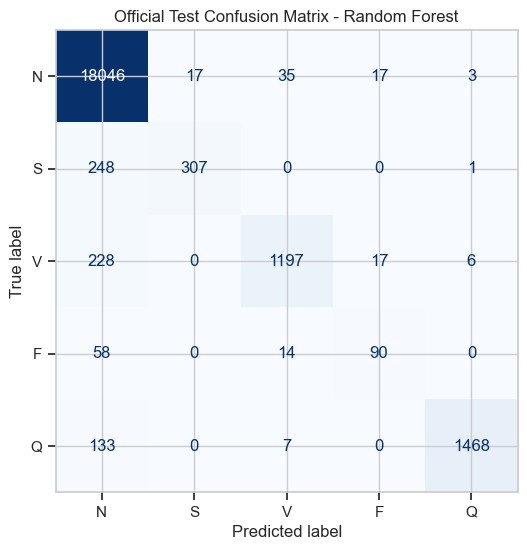

In [18]:
cm_test = confusion_matrix(y_test, y_test_pred, labels=sorted(LABEL_MAP))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[LABEL_MAP[idx] for idx in sorted(LABEL_MAP)])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title(f'Official Test Confusion Matrix - {selected_model_name}')
plt.show()

<div style="border-left:6px solid #1D9E75;background:linear-gradient(90deg,#E1F5EE 0%,#F7FCFA 100%);border-radius:0 12px 12px 0;padding:14px 18px;margin:8px 0 14px 0;">
  <div style="font-size:12px;letter-spacing:0.08em;text-transform:uppercase;color:#0F6E56;font-weight:800;">Section 9</div>
  <div style="font-size:24px;color:#085041;font-weight:800;margin-top:2px;">Inference on One Unseen ECG Heartbeat</div>
</div>

The final section shows how the selected model behaves on a single unseen heartbeat from the official test set. The notebook reports the fine-grained class prediction and the derived normal-vs-abnormal interpretation.


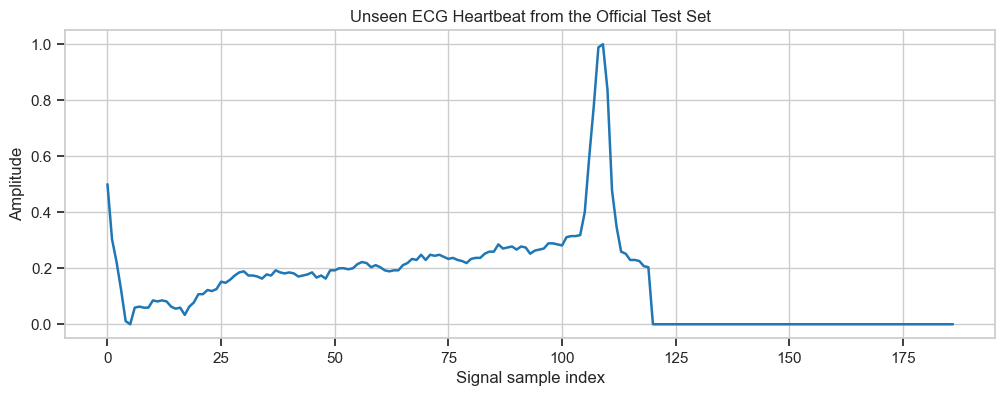

True class: S - Supraventricular ectopic beat
Predicted class: N - Normal beat
Derived interpretation (true): Abnormal
Derived interpretation (predicted): Normal
Result: Incorrect prediction


,class_id,class_code,heartbeat_type,probability
0,0,N,Normal beat,0.6995
2,2,V,Ventricular ectopic beat,0.1731
1,1,S,Supraventricular ectopic beat,0.0747
4,4,Q,Unclassifiable beat,0.0527
3,3,F,Fusion beat,0.0000


In [19]:
rng = np.random.default_rng(RANDOM_STATE)
abnormal_indices = np.where(y_test.to_numpy() != 0)[0]
example_index = int(rng.choice(abnormal_indices))

x_example = X_test.iloc[[example_index]]
y_true_example = int(y_test.iloc[example_index])
y_pred_example = int(final_model.predict(x_example)[0])

signal = x_example.iloc[0].to_numpy()
plt.figure(figsize=(12, 4))
plt.plot(signal, linewidth=1.8)
plt.title('Unseen ECG Heartbeat from the Official Test Set')
plt.xlabel('Signal sample index')
plt.ylabel('Amplitude')
plt.show()

print('True class:', LABEL_MAP[y_true_example], '-', LABEL_DESCRIPTION[y_true_example])
print('Predicted class:', LABEL_MAP[y_pred_example], '-', LABEL_DESCRIPTION[y_pred_example])
print('Derived interpretation (true):', BINARY_MAP[y_true_example])
print('Derived interpretation (predicted):', BINARY_MAP[y_pred_example])
print('Result:', 'Correct prediction' if y_true_example == y_pred_example else 'Incorrect prediction')

if hasattr(final_model, 'predict_proba'):
    proba = final_model.predict_proba(x_example)[0]
    proba_df = pd.DataFrame({
        'class_id': sorted(LABEL_MAP),
        'class_code': [LABEL_MAP[idx] for idx in sorted(LABEL_MAP)],
        'heartbeat_type': [LABEL_DESCRIPTION[idx] for idx in sorted(LABEL_MAP)],
        'probability': proba,
    }).sort_values('probability', ascending=False)
    display(proba_df.round(4))
elif hasattr(final_model, 'decision_function'):
    decision_values = final_model.decision_function(x_example)
    if np.ndim(decision_values) == 1:
        decision_values = np.expand_dims(decision_values, axis=0)
    decision_df = pd.DataFrame({
        'class_id': sorted(LABEL_MAP),
        'class_code': [LABEL_MAP[idx] for idx in sorted(LABEL_MAP)],
        'decision_score': decision_values[0],
    }).sort_values('decision_score', ascending=False)
    display(decision_df.round(4))
else:
    print('Probability-style outputs are not available for this final model.')

<div style="border-left:6px solid #1D9E75;background:linear-gradient(90deg,#E1F5EE 0%,#F7FCFA 100%);border-radius:0 12px 12px 0;padding:14px 18px;margin:8px 0 14px 0;">
  <div style="font-size:12px;letter-spacing:0.08em;text-transform:uppercase;color:#0F6E56;font-weight:800;">Section 10</div>
  <div style="font-size:24px;color:#085041;font-weight:800;margin-top:2px;">Conclusion</div>
</div>

This notebook demonstrates a complete classical machine learning workflow for ECG heartbeat classification. The selected model is chosen using a fair validation protocol and justified primarily by macro F1-score rather than accuracy alone.



In [20]:
conclusion = f"""
### Final Takeaways

- **Selected model:** {selected_model_name}
- **Official test Macro F1:** {official_test_metrics['macro_f1']:.4f}
- **Official test Macro Recall:** {official_test_metrics['macro_recall']:.4f}
- **Official test Accuracy:** {official_test_metrics['accuracy']:.4f}

Accuracy remained a secondary metric because the dataset is strongly imbalanced. The final decision therefore prioritized balanced multiclass performance and the ability to recover abnormal heartbeat categories more reliably.
"""

display(Markdown(conclusion))


### Final Takeaways

- **Selected model:** Random Forest
- **Official test Macro F1:** 0.8290
- **Official test Macro Recall:** 0.7687
- **Official test Accuracy:** 0.9642

Accuracy remained a secondary metric because the dataset is strongly imbalanced. The final decision therefore prioritized balanced multiclass performance and the ability to recover abnormal heartbeat categories more reliably.
